# Random Seed

https://www.kaggle.com/code/mehmetlaudatekman/lstm-text-classification-pytorch

In [1]:
import random
import torch
import numpy as np
import json

def set_seed(seed):
    # 設定 Python 隨機數生成器的種子
    random.seed(seed)
    
    # 設定 numpy 隨機數生成器的種子
    np.random.seed(seed)
    
    # 設定 PyTorch 隨機數生成器的種子
    torch.manual_seed(seed)
    
    # 如果使用 GPU，設置 CUDA 隨機數生成器的種子
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        
    # 設置 PyTorch 預測模式，保證可重現性
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# 設定隨機種子
set_seed(22)


/home/yijiu/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [1]:
import sys
print(sys.executable)


/home/yijiu/miniconda3/envs/FiNER_MASK/bin/python


In [2]:
from transformers import AutoTokenizer
import torch
import spacy
from collections import Counter


# spacy_tokenizer = spacy.load("en_core_web_sm")
spacy_tokenizer = spacy.load("en_core_web_sm", disable=["ner", "parser"]) 

# tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
# tokenizer = AutoTokenizer.from_pretrained("yiyanghkust/finbert-pretrain")

# tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased", local_files_only=True)
# vocab_size = tokenizer.vocab_size
# print(vocab_size)

# 設定預設值
CLASSIFICATION_MISSING_VALUE = -100
NUMERIC_MISSING_VALUE = torch.finfo(torch.float32).max  # 3.4028235e+38

### Spacy
- 建立 vocab

[PAD] = 0  # Padding token

[UNK] = 1  

In [3]:
import json
import spacy
from collections import Counter
from tqdm import tqdm
import multiprocessing

# Tokenization（支援 multiprocessing）
def tokenize(text):
    """ 使用 Spacy 進行 tokenization，並轉換為小寫 """
    return [token.text.lower() for token in spacy_tokenizer(text) if not token.is_punct]

def tokenize_batch(texts):
    """ 用 multiprocessing 加速 tokenization """
    with multiprocessing.Pool(processes=multiprocessing.cpu_count() // 2) as pool:
        tokenized_texts = list(tqdm(pool.imap(tokenize, texts), total=len(texts), desc="Tokenizing"))
    return tokenized_texts

# 建立詞彙表（vocab）
def get_vocab_counter(sentences, i):
    counter = Counter()
    
    # 使用 multiprocessing 進行 tokenization
    tokenized_sentences = tokenize_batch(sentences)
    
    # 使用批量更新來減少 function 呼叫次數
    for tokens in tqdm(tokenized_sentences, desc="Building vocab"):
        counter.update(tokens)
    
    print(f"Total unique tokens: {len(counter)}")  # 確保統計正確
    
    with open(f"vocab_all_train_{i}.json", "w", encoding="utf-8") as f:
        json.dump(counter, f, ensure_ascii=False, indent=4)
        
    return counter
    
# 加入 tqdm 監控 get_all_context 的進度
def get_all_context(batch):
    all_text = []

    for job in tqdm(batch, desc="Processing contexts"):
        context_t = job['context'].get("context_t", "")
        all_text.append(context_t)
        
    return all_text

for i in range(1, 6):
    print(f"Process part {i}")
    with open(f'processed_data_task1/train_split/train_data_part_{i}.jsonl', 'r', encoding="utf-8") as file:
        train_data = [json.loads(line) for line in file]
        
    train_text = get_all_context(train_data)
    vocab_counter = get_vocab_counter(train_text, i)

Process part 1


Building vocab: 100%|█████████████| 1000000/1000000 [00:02<00:00, 433326.71it/s]


Total unique tokens: 205971
Process part 2


Building vocab: 100%|█████████████| 1000000/1000000 [00:02<00:00, 401418.63it/s]


Total unique tokens: 223466
Process part 3


...

Total unique tokens: 229875
Process part 4


Building vocab: 100%|█████████████| 1000000/1000000 [00:02<00:00, 379526.49it/s]


Total unique tokens: 251843
Process part 5


Building vocab: 100%|███████████████| 280499/280499 [00:00<00:00, 331446.19it/s]


Total unique tokens: 108266


In [4]:

counter = Counter()

# 讀取並合併所有部分的 Counter
for i in range(6):
    with open(f'vocab_all_train_{i}.json', 'r', encoding='utf-8') as file:
        part_counter = json.load(file)
        counter.update(part_counter)  # 合併 Counter

# 檢查合併後的詞彙數量
print(f"Total unique tokens: {len(counter)}")

# 存成 JSON
with open("vocab_all_train_full.json", "w", encoding="utf-8") as f:
    json.dump(counter, f, ensure_ascii=False, indent=4)


Total unique tokens: 640842


### 更新不同的 vocab

In [3]:
from collections import Counter
import re

vocab_size = 100000
min_freq = 2

with open("vocab/vocab_all_train_full.json", "r", encoding="utf-8") as f:
    counter = Counter(json.load(f))
print(f'Raw counter: {len(counter)}')


number_pattern = r"(\d+[\d,.]*\d)|([.]\d+)|\d+"

# 先把數字變成 <NUM>，並過濾低頻詞
processed_counter = Counter()
for word, freq in counter.items():
    normalized_word = "<NUM>" if re.fullmatch(number_pattern, word) else word
    processed_counter[normalized_word] += freq
most_common = processed_counter.most_common(vocab_size - 3)
    
# most_common = counter.most_common(vocab_size - 3)
# print(most_common)
vocab = {word: idx + 3 for idx, (word, freq) in enumerate(most_common) if freq >= min_freq}
vocab["<PAD>"] = 0  # Padding token
vocab["<UNK>"] = 1  # Unknown token
vocab["<SEP>"] = 2

print(f"Vocab size: {len(vocab)}")
# 存成 JSON 檔案
with open("vocab_100k.json", "w", encoding="utf-8") as f:
    json.dump(vocab, f, ensure_ascii=False, indent=4)


Raw counter: 640842
Vocab size: 97918


##### Test

In [7]:
with open('processed_data_task1_smaller/test_1k.jsonl', 'r', encoding='utf-8') as file:
    test_data = [json.loads(line) for line in file]

In [ ]:
process_batch([test_data[0]], ["tag", "time", "scale", "negative", "fact"], spacy_tokenizer)

## Pre-process

In [4]:
# Pre-process Helper Function

# 加載 vocab
with open("vocab_100k.json", "r", encoding="utf-8") as f:
    vocab = json.load(f)

print(len(vocab))
# 將文本轉換為數字索引

def encode_sentence(doc, vocab, max_length = 512):
    # sentence = sentence.lower()
    # tokens = spacy_tokenizer(sentence)

    encoded = [vocab.get(token.text.lower(), vocab["<UNK>"]) for token in doc]
    # offsets = [token.idx for token in doc]

    if len(encoded) < max_length:
        encoded += [vocab["<PAD>"]] * (max_length - len(encoded))
    else:
        encoded = encoded[:max_length]
    
    return torch.tensor(encoded, dtype=torch.long)
    

def num_mask_preprocess(text):
    """把數字替換成 <NUM>"""
    return re.sub(r"(\d+[\d,.]*\d)|([.]\d+)|\d+", "<NUM>", text) if text else None

    

97918


In [5]:
from concurrent.futures import ThreadPoolExecutor
import re
import spacy
from tqdm import tqdm
    
def process_batch(batch, target_attrs, tokenizer, vocab = vocab):
    """批量處理數據，提高 Tokenization 速度"""

    batch_results = []

    # 先批量處理文本，合併為一個列表
    texts = [
        f"{job['context'].get('context_t', '')} <SEP> "
        f"{job['document']['document_type']}; {job['document']['period_end_date']}; {job['document']['fiscal_year']}; {job['document']['period_focus']} <SEP> "
        f"{job['context'].get('context_p', '')} <SEP> {job['context'].get('context_n', '')}"
        for job in batch
    ]

    # 用 `spacy.pipe()` 批量 Tokenization（比逐行快 3~5 倍）
    tokenized_texts = list(tokenizer.pipe(texts, batch_size=len(batch)))
    
    for job, doc, full_context in zip(batch, tokenized_texts, texts):
        # 將 Token 轉換為 ID
        # token_ids = [vocab.get(token.text.lower(), vocab["<UNK>"]) for token in doc if not token.is_punct]
        token_ids = encode_sentence(doc, vocab)
        
        for i, target in enumerate(job['targets']):
            target_data = {
                "job_id": job["job_id"],
                "seq_id": target["seq_id"],
                "context": full_context,  # 使用預先構建的 full_context
                "input_ids": token_ids,
                "value": convert_span_to_number(target['text']),
                "doc_link": job['document']['document_link'],
            }

            # 處理 target_attrs 屬性
            for attr in target_attrs:
                if attr in ["tag", "time", "scale", "negative"]:  
                    target_data[attr] = CLASSIFICATION_MISSING_VALUE
                elif attr == "fact":  
                    target_data[attr] = NUMERIC_MISSING_VALUE

            # 對應 gold value
            gold_values = job['golds'][i]['value']
            for attr_idx, attr in enumerate(target['attribute']):
                value = gold_values[attr_idx]
                if attr == 'tag':
                    value = 'standard_rare' if value in standard_rare_tags else value
                    target_data['tag'] = tag2id.get(value, CLASSIFICATION_MISSING_VALUE)
                elif attr == 'time':
                    target_data['time'] = time2id.get(value, CLASSIFICATION_MISSING_VALUE)
                elif attr == 'fact':
                    # target_data['fact'] = float(value) if value else NUMERIC_MISSING_VALUE
                    # target_data['negative'] = 1 if float(value) and value < 0 else CLASSIFICATION_MISSING_VALUE
                    if value:
                        target_data['fact'] = float(value)
                        target_data['negative'] = 1 if value < 0 else 0
                    else:
                        target_data['fact'] = NUMERIC_MISSING_VALUE
                        target_data['negative'] = CLASSIFICATION_MISSING_VALUE
                        
                elif attr == 'scale':
                    target_data['scale'] = scale2id.get(value, CLASSIFICATION_MISSING_VALUE)

            batch_results.append(target_data)

    return batch_results


In [6]:
# IterableDataset

with open('processed_data_task1/counter/tag_count_train_data.json', 'r', encoding = 'utf-8') as file:
# with open('processed_iterable_dataset/counter/train_8k.json', 'r', encoding = 'utf-8') as file:
    tag_counter = json.load(file)
    
# 想讓數量多的類別在前面

tag_counter = dict(sorted(tag_counter.items(), key = lambda item:item[1], reverse=True))
print(len(tag_counter))
count_threshold = 10
standard_rare_tags = {tag for tag, count in tag_counter.items() if count < count_threshold}
tag_list = [tag for tag in tag_counter.keys() if tag not in standard_rare_tags]
print(tag_list[:5])
print(f'Length of standard_rare_tags: {len(standard_rare_tags)}')
print(f'Length of all tags: {len(tag_list)}')

id2tag = {idx: tag for idx, tag in enumerate(tag_list)}
tag2id = {tag: idx for idx, tag in enumerate(tag_list)}

time_list = ['instant; past', 'instant; current', 'instant; future', 'period; past', 'period; current', 'period; future', 'period; past_current', 'period; current_future', 'period; past_future']
id2time = {idx: time for idx, time in enumerate(time_list)}
time2id = {time: idx for idx, time in enumerate(time_list)}

scale_list = [str(i) for i in range(-12, 13)]
id2scale = {idx: scale for idx, scale in enumerate(scale_list)}
scale2id = {scale: idx for idx, scale in enumerate(scale_list)}
# with open('processed_data_task1_smaller/counter/train_100k.json')

978
['custom', 'standard_rare', 'us-gaap:DebtInstrumentInterestRateStatedPercentage', 'us-gaap:DebtInstrumentBasisSpreadOnVariableRate1', 'us-gaap:DebtInstrumentFaceAmount']
Length of standard_rare_tags: 0
Length of all tags: 978


In [7]:
import locale
from word2number import w2n

def convert_span_to_number(span):
    """
    將 span 轉換為數字。
    """
    span = span.strip()
    
    # 嘗試直接轉換為數字
    try:
        return locale.atof(span.replace(",", ""))  # 去掉千分位逗號並轉換
    except ValueError:
        pass  # 不是標準數字，繼續嘗試解析
    
    # 嘗試將文字轉為數字
    try:
        return w2n.word_to_num(span.lower())
    except ValueError:
        pass  # 不是可解析的數字
    
    return None  # 解析失敗，返回 None


#### IterableDataset

In [8]:
import random
from torch.utils.data import DataLoader, IterableDataset, get_worker_info

class MultiTaskIterableDataset(IterableDataset):
    ''' 讀取原始 JSONL 檔案，進行前處理'''

    def __init__(self, files, target_attrs, tokenizer, batch_size=32, num_workers=8):
        self.files = files
        self.target_attrs = target_attrs
        self.tokenizer = tokenizer
        self.batch_size = batch_size
        self.num_workers = num_workers
    
    def _get_sharded_lines(self, file_path):
        """確保多進程時，每個 worker 讀不同的部分"""
        worker_info = get_worker_info()
        if worker_info is None:  # 單進程模式
            start, step = 0, 1
        else:
            start, step = worker_info.id, worker_info.num_workers  # worker id & 總數

        with open(file_path, "r", encoding="utf-8") as f:
            for i, line in enumerate(f):
                if i % step == start:  # 讓不同 worker 讀不同的行
                    yield line
    # def __iter__(self):
    #     """逐行讀取 JSONL 並轉換為數據格式"""
    #     for file_path in self.files:
    #         for line in self._get_sharded_lines(file_path):
    #             raw_data = json.loads(line)
                # processed_data = process_batch([raw_data], self.target_attrs, self.tokenizer)
                # for item in processed_data:
                #     yield item
    def __iter__(self):
        """逐行讀取 JSONL，批量處理文本，並轉換為數據格式"""
        buffer = []  # 暫存一批數據
        for file_path in self.files:
            for line in self._get_sharded_lines(file_path):
                raw_data = json.loads(line)
                buffer.append(raw_data)

                # 當累積到 batch_size，批量處理
                if len(buffer) >= self.batch_size:
                    yield from process_batch(buffer, self.target_attrs, self.tokenizer)
                    buffer = []  # 清空 buffer
        
        # 處理最後剩餘的 buffer
        if buffer:
            yield from process_batch(buffer, self.target_attrs, self.tokenizer)


In [9]:
# buffer_size = 3000
batch_size = 512
num_workers = 4
target_attrs = ["tag", "time", "scale", "negative", "fact"]

train_dataset = MultiTaskIterableDataset(
    files = ["processed_data_task1/train_data_shuffled.jsonl"],
    # files = ["processed_data_task1_smaller/train_8k.jsonl"],
    
    target_attrs = target_attrs,
    tokenizer = spacy_tokenizer)

valid_dataset = MultiTaskIterableDataset(
    files = ["processed_data_task1/valid_data.jsonl"], 
    target_attrs = target_attrs,
    tokenizer = spacy_tokenizer)

test_dataset = MultiTaskIterableDataset(
    files = ["processed_data_task1/test_data.jsonl"], 
    target_attrs = target_attrs,
    tokenizer = spacy_tokenizer)

train_dataloader = DataLoader(
    train_dataset, batch_size = batch_size, num_workers = num_workers, persistent_workers=True
)
valid_dataloader = DataLoader(
    valid_dataset, batch_size = batch_size, num_workers = num_workers, persistent_workers=True
)
test_dataloader = DataLoader(
    test_dataset, batch_size = batch_size, num_workers = num_workers, persistent_workers=True
)

In [10]:
# 先把 MultiTaskIterableDataset 轉換為 JSONL
import json

def save_iterable_dataset(output_file, dataloader, approx_num=None):
    with open(output_file, "w", encoding="utf-8") as f:
        for batch in tqdm(dataloader, desc=f"Processing {output_file}", total=approx_num):
    
            try:
                batch_size = len(batch["input_ids"])  # 確保 batch size 正確
            except KeyError:
                print(f"Skipping batch due to missing 'input_ids' key.")
                continue
            
            for i in range(batch_size):
                json_obj = {}
                for key in batch:
                    value = batch[key][i]
                    
                    # 檢查是否為 Tensor，轉成 list
                    if isinstance(value, torch.Tensor):
                        json_obj[key] = value.tolist()
                    else:
                        json_obj[key] = value  # 直接儲存非 Tensor 型態 (如 str, int)
    
                f.write(json.dumps(json_obj) + "\n")

# save_iterable_dataset('processed_iterable_dataset/train_100k.jsonl', train_dataloader)
# save_iterable_dataset('processed_iterable_dataset/valid_50k.jsonl', valid_dataloader)
# save_iterable_dataset('processed_iterable_dataset/test_50k.jsonl', test_dataloader)
save_iterable_dataset('processed_iterable_dataset/lstm/train_full_voc_100k_mask.jsonl', train_dataloader)
save_iterable_dataset('processed_iterable_dataset/lstm/valid_full_voc_100k_mask.jsonl', valid_dataloader)
save_iterable_dataset('processed_iterable_dataset/lstm/test_full_voc_100k_mask.jsonl', test_dataloader)
# save_iterable_dataset('processed_iterable_dataset/lstm/train_8k_voc_100k_mask.jsonl', train_dataloader)


Processing processed_iterable_dataset/lstm/train_full_voc_100k_mask.jsonl: 18783it [1:30:57,  3.44it/s]
Processing processed_iterable_dataset/lstm/valid_full_voc_100k_mask.jsonl: 2216it [11:17,  3.27it/s]
Processing processed_iterable_dataset/lstm/test_full_voc_100k_mask.jsonl: 2687it [13:41,  3.27it/s]


#### Load Processed Iterable Dataset

In [11]:
# 讀取處理後的 JSONL

import json
import torch
from torch.utils.data import DataLoader, IterableDataset, get_worker_info

class ProcessedIterableDataset(IterableDataset):
    def __init__(self, files):
        self.files = files

    def _get_sharded_lines(self, file_path):
        """確保多進程時，每個 worker 讀不同的部分"""
        worker_info = get_worker_info()
        if worker_info is None:  # 單進程模式
            start, step = 0, 1
        else:
            start, step = worker_info.id, worker_info.num_workers  # worker id & 總數

        with open(file_path, "r", encoding="utf-8") as f:
            for i, line in enumerate(f):
                if i % step == start:  # 讓不同 worker 讀不同的行
                    yield line

    def __iter__(self):
        """讀取 JSONL 並轉換為合適格式"""
        sample_count = 0
        for file_path in self.files:
            for line in self._get_sharded_lines(file_path):
                raw_data = json.loads(line)

                # 把 list 轉回 torch.Tensor
                processed_data = {
                    key: torch.tensor(value) if isinstance(value, list) else value
                    for key, value in raw_data.items()
                }
                
                yield processed_data

            

train_files = ["processed_iterable_dataset/lstm/train_full_voc_100k_mask.jsonl"]
valid_files = ["processed_iterable_dataset/lstm/valid_full_voc_100k_mask.jsonl"]
test_files = ["processed_iterable_dataset/lstm/test_full_voc_100k_mask.jsonl"]

train_dataset = ProcessedIterableDataset(train_files)

valid_dataset = ProcessedIterableDataset(valid_files)

test_dataset = ProcessedIterableDataset(test_files)

batch_size = 512
train_loader = DataLoader(train_dataset, batch_size = batch_size, num_workers = 4, drop_last = False)
valid_loader = DataLoader(valid_dataset, batch_size = batch_size, num_workers = 4, drop_last = False)
test_loader = DataLoader(test_dataset, batch_size = batch_size, num_workers = 4, drop_last = False)

In [12]:
import os

def count_lines(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        return sum(1 for _ in f)

# 計算訓練資料大約的 batch 數
train_total_samples = sum(count_lines(f) for f in train_files)
train_approx_batches = train_total_samples // batch_size

valid_total_samples = sum(count_lines(f) for f in valid_files)
valid_approx_batches = valid_total_samples // batch_size

test_total_samples = sum(count_lines(f) for f in test_files)
test_approx_batches = test_total_samples // batch_size


print(f"Train 預計數量: {train_total_samples}, 預計 {train_approx_batches} 個 batch")
print(f"Valid 預計數量: {valid_total_samples}, 預計 {valid_approx_batches} 個 batch")
print(f"Test 預計數量: {test_total_samples}, 預計 {test_approx_batches} 個 batch")

Train 預計數量: 9615922, 預計 18781 個 batch
Valid 預計數量: 1133989, 預計 2214 個 batch
Test 預計數量: 1375321, 預計 2686 個 batch


## Count

#### 計算 tag, scale, negative, time 的類別個數
計算後存成 JSON，之後可以直接用

In [13]:
from collections import Counter
import json

def count_classes_in_jsonl(file_paths, target_attr="tag"):
    class_counts = Counter()
    for file_path in file_paths:
        with open(file_path, "r", encoding="utf-8") as f:
            for line in f:
                data = json.loads(line)
                class_counts[data[target_attr]] += 1
                
    target_path = f'processed_iterable_dataset/counter/train_spacy_full_100k_mask_{target_attr}.json'
    
    with open(target_path, 'w', encoding = 'utf-8') as f:
        json.dump(class_counts, f, ensure_ascii=False, indent=4)
    
    print(f"{target_attr} count save to {target_path}")
    
    return class_counts

train_files = ["processed_iterable_dataset/lstm/train_full_voc_100k_mask.jsonl"]

train_tag_counts = count_classes_in_jsonl(train_files, "tag")
train_time_counts = count_classes_in_jsonl(train_files, "time")
train_neg_counts = count_classes_in_jsonl(train_files, "negative")
train_scale_counts = count_classes_in_jsonl(train_files, "scale")

tag count save to processed_iterable_dataset/counter/train_spacy_full_100k_mask_tag.json
time count save to processed_iterable_dataset/counter/train_spacy_full_100k_mask_time.json
negative count save to processed_iterable_dataset/counter/train_spacy_full_100k_mask_negative.json
scale count save to processed_iterable_dataset/counter/train_spacy_full_100k_mask_scale.json


In [17]:
# load counter result

def load_counter(target_path, target_attr):
    target_file = f'{target_path}_{target_attr}.json'

    with open(target_file, "r", encoding='utf-8') as f:
        data = json.load(f)
    return data

# target_path = f'processed_iterable_dataset/counter/train_{train_size}k'
target_path = f'processed_iterable_dataset/counter/train_spacy_full_100k_mask'

train_tag_counts = load_counter(target_path, "tag")
train_tag_counts.pop('-100', None)
num_tag_samples = [train_tag_counts.get(str(tag2id[tag]), 0) for tag in tag_list]
print('tag',len(train_tag_counts))

train_time_counts = load_counter(target_path, "time")
train_time_counts.pop('-100', None)
num_time_samples = [train_time_counts.get(str(time2id[time]), 0) for time in time_list]
print('time')
print(train_time_counts)

train_neg_counts = load_counter(target_path, "negative")
train_neg_counts.pop('-100', None)
num_neg_samples = [train_neg_counts.get(neg, 0) for neg in sorted(train_neg_counts.keys())]
print('negative')
print(train_neg_counts)

train_scale_counts = load_counter(target_path, "scale")
train_scale_counts.pop('-100', None)
num_scale_samples = [train_scale_counts.get(str(scale2id[scale]), 0) for scale in scale_list]
print('scale')
print(train_scale_counts)

tag 978
time
{'4': 1652232, '3': 2310806, '2': 188920, '1': 2572189, '5': 141871, '6': 925306, '0': 1790832, '8': 6839, '7': 4608}
negative
{'0': 9253463, '1': 261595}
scale
{'18': 4332125, '10': 1554493, '12': 2022151, '15': 668117, '21': 249005, '8': 22131, '13': 170, '9': 303, '17': 595, '6': 144, '14': 178, '24': 362, '16': 413, '11': 203, '20': 23, '19': 34, '4': 10, '7': 7, '5': 1, '3': 1}


## Model

In [18]:
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence
from transformers import AutoModel

class MultiTaskLSTM(nn.Module):
    def __init__(self, vocab_size, num_layers, embedding_dim, hidden_dim, num_tags, num_times, num_scales):
        super(MultiTaskLSTM, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        self.lstm = nn.LSTM(input_size = embedding_dim, 
                            hidden_size = hidden_dim, 
                            num_layers = num_layers, 
                            dropout=0.3,
                            batch_first = True, 
                            bidirectional = True)
        
        self.fc = nn.Linear(hidden_dim * 2, hidden_dim)  # bidirectional LSTM
        
        self.hidden_size = hidden_dim * 2  
        
        self.tag_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2), 
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim // 2, num_tags)
        )

        self.time_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2), 
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(hidden_dim // 2, num_times)
        )

        self.scale_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2), 
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim // 2, num_scales)
        )

        self.negative_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2), 
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(hidden_dim // 2, 2)
        )
        
        
    # def forward(self, input_ids, start_tokens, end_tokens):
    def forward(self, input_ids):
        
        # print(f"Max index in input_ids: {input_ids.max()}, vocab_size: {self.embedding.num_embeddings}")

        # print(f"Min index in input_ids: {input_ids.min()}")
        text_lengths = (input_ids != vocab["<PAD>"]).sum(dim=1).cpu()
        
        embedded = self.embedding(input_ids)  # (batch_size, seq_len, embed_dim)

        packed_embedded = pack_padded_sequence(embedded, text_lengths, batch_first=True, enforce_sorted=False)
        packed_output, (hidden_state, cell_state) = self.lstm(packed_embedded)

        # BiLSTM：拼接最後一層的前向與後向 hidden state
        hidden = torch.cat((hidden_state[-2,:,:], hidden_state[-1,:,:]), dim=1)

        # 轉換維度
        shared_features = self.fc(hidden)
                        
        tag_logits = self.tag_head(shared_features)
        time_logits = self.time_head(shared_features)      
        scale_logits = self.scale_head(shared_features) 
        negative_logits = self.negative_head(shared_features)
        
        
        return {
            "tag": tag_logits,
            "time": time_logits,
            "scale": scale_logits,
            "negative": negative_logits,
        }


## Loss

In [19]:
# hits@k
import torch

def hits_at_k(predictions, targets, k=5):
    """
    計算 Hits@K 指標
    :param predictions: (batch_size, num_tags) - 預測分數
    :param targets: (batch_size, num_tags) - 目標標籤 (one-hot 或 multi-hot)
    :param k: 取前 K 個預測標籤
    :return: Hits@K 平均值
    """
    valid_mask = targets != -100  # 只保留有效的索引
    targets = targets[valid_mask]
    predictions = predictions[valid_mask]
    # print(f"targets.shape: {targets.shape}, targets min: {targets.min()}, targets max: {targets.max()}")
    # assert targets.min() >= 0, f"targets 包含負數: {targets}"

    top_k_preds = torch.topk(predictions, k, dim=-1).indices  # 取得 top-K 標籤索引

       # 確保 targets 維度正確
    if targets.dim() == 1:  # 若 targets 是索引格式 (batch_size,)
        targets = torch.nn.functional.one_hot(targets, num_classes=predictions.size(1))

    targets = targets.float()  # 確保是 float tensor

    # 判斷是否命中 top-K (batch_size, k) → (batch_size,)
    hits = torch.any(targets.gather(1, top_k_preds), dim=1).float()

    return hits.mean().item()  # 計算平均命中率

In [20]:
device = "cuda" if torch.cuda.is_available() else "cpu"
# device = 'cpu'
print(device)


cuda


In [21]:
# time loss
from sklearn.utils.class_weight import compute_class_weight
import torch
import numpy as np

# 取得 time 類別的出現次數
time_class_counts = torch.tensor(num_time_samples)

total_samples = sum(train_time_counts.values())
num_classes = len(train_time_counts)

time_class_weights = {
    cls: total_samples / (num_classes * count) 
    for cls, count in train_time_counts.items()
}
time_class_weights = dict(sorted(time_class_weights.items(), key = lambda item:item[0]))
time_class_weights = list(time_class_weights.values())

time_smoothed_weights = np.log1p(time_class_weights)

MIN_WEIGHT =  1 # 設定最小值
time_smoothed_weights = np.clip(time_smoothed_weights, MIN_WEIGHT, None)
time_smoothed_weights[0] = 1.5
time_smoothed_weights[6] = 1.5
print(time_smoothed_weights)
time_class_weights = torch.tensor(time_smoothed_weights, dtype=torch.float).to(device)
time_loss_fn = nn.CrossEntropyLoss(weight = time_class_weights, ignore_index = CLASSIFICATION_MISSING_VALUE)

[1.5        1.         1.89346831 1.         1.         2.14165987
 1.5        5.44814686 5.05538105]


In [22]:
# scale loss
scale_class_weights = {
    15: 1.2,  21: 1.5
}
num_classes = len(scale_list)
weights_list = [scale_class_weights.get(i, 1.0) for i in range(num_classes)]

scale_class_weights = torch.tensor(weights_list, dtype=torch.float).to(device)

# 定義 loss function
scale_loss_fn = nn.CrossEntropyLoss(weight=scale_class_weights, ignore_index=CLASSIFICATION_MISSING_VALUE)

In [23]:
# netagive loss

import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    '''https://doi.org/10.1109/tpami.2018.2858826'''
    def __init__(self, alpha=0.25, gamma=2.0, reduction="mean", ignore_index = CLASSIFICATION_MISSING_VALUE):
        """
        alpha: 平衡因子 (適用於正負類不平衡)
        gamma: 縮放因子 (讓難分類的樣本 loss 權重變高)
        reduction: 可選 ["mean", "sum", "none"]，控制 loss 的輸出方式
        """
        super(FocalLoss, self).__init__()
        if isinstance(alpha, (float, int)):  # 確保 alpha 是 tensor
            self.alpha = torch.tensor([1 - alpha, alpha])  # alpha_neg, alpha_pos
        else:
            self.alpha = torch.tensor(alpha) 
        self.gamma = gamma
        self.reduction = reduction
        self.ce_loss = nn.CrossEntropyLoss(reduction="none", ignore_index=CLASSIFICATION_MISSING_VALUE)
        self.ignore_index = ignore_index

    def forward(self, logits, targets):
        """
        logits: 預測值 (模型輸出，形狀 [batch_size, 2]，未經 softmax)
        targets: 標籤值 (形狀 [batch_size]，0 或 1)
        """
        device = logits.device
        self.alpha = self.alpha.to(device)
        # print('focal loss', targets)
        # print(targets.shape)
        if targets.dim() > 1:
            targets = targets.argmax(dim=-1)
        
         # 1. 移除 ignore_index
        valid_mask = (targets != self.ignore_index)
        targets = targets[valid_mask]
        logits = logits[valid_mask]

        # if targets.numel() == 0:  # 避免 loss 計算時出現空值
        #     return torch.tensor(0.0, device=device, requires_grad=True)
        # if torch.any(filtered_targets < 0) or torch.any(filtered_targets >= logits.shape[-1]):
        #     raise ValueError(f"Invalid target values detected: {filtered_targets}")
        
        # 2. 計算 CrossEntropyLoss
        ce_loss = self.ce_loss(logits, targets)  # 計算 cross entropy loss
        pt = torch.exp(-ce_loss)  # 選擇正確類別的機率
        
        # 4. 計算 focal loss 權重
        focal_weight = (1 - pt) ** self.gamma  # (1 - p_t)^gamma
        alpha_weight = self.alpha.gather(0, targets.data.view(-1))  # 根據 targets 索引 alpha

        loss = alpha_weight * focal_weight * ce_loss

        # 5. 根據 reduction 返回 loss
        if self.reduction == "mean":
            return loss.mean() if loss.numel() > 0 else torch.tensor(0.0, device=device, requires_grad=True)
        elif self.reduction == "sum":
            return loss.sum()
        else:
            return loss  # 不做平均，返回 batch loss

neg_loss = FocalLoss(alpha=0.25, gamma=2.0, reduction="mean")

In [24]:
# tag loss
import torch
import torch.nn as nn
import torch.nn.functional as F

class CB_CE_Loss(nn.Module):
    '''
    https://ieeexplore.ieee.org/abstract/document/8953804
    '''
    def __init__(self, num_samples, beta=0.99, ignore_index=CLASSIFICATION_MISSING_VALUE):
        """
        Args:
            num_samples: list or tensor, 每個類別的樣本數
            beta: 控制 class-balanced 權重的超參數 (通常取 0.99)
        """
        super(CB_CE_Loss, self).__init__()
        
        # 計算 Class-Balanced 權重
        effective_num = 1.0 - torch.pow(torch.tensor(beta), torch.tensor(num_samples))
        weights = (1.0 - beta) / (effective_num + 1e-8)
        # self.weights = weights / torch.sum(weights)  # normalize
        # self.weights = weights
        self.weights = torch.clamp(weights, max=5.0)  # 避免 loss 被過度放大

        self.ignore_index = ignore_index
        
    def forward(self, logits, targets):
        """
        Args:
            logits: (batch_size, num_classes) 模型輸出的 logits
            targets: (batch_size,) 類別索引標籤
        Returns:
            CB-CE Loss 值
        """
        
        if targets.dim() > 1:
            targets = targets.argmax(dim=-1)
            
        valid_mask = (targets != self.ignore_index)  # 只對有效的 targets 計算 loss
        targets = targets[valid_mask]
        logits = logits[valid_mask]
        
        # 計算標準 CE Loss
        ce_loss = F.cross_entropy(logits, targets, reduction='none', ignore_index=self.ignore_index)
        
        # 依照類別權重調整 loss
        class_weights = self.weights.to(logits.device)
        weighted_loss = ce_loss * class_weights[targets]
        
        # weighted_loss = ce_loss * class_weights[targets] * weight_mask.float()
        return torch.mean(weighted_loss)

        # return weighted_loss.sum() / weight_mask.sum()  # 只對有效樣本取平均

# train_tag_counts = get_value_counts(train_loader, "tag")
# num_tag_samples = [train_tag_counts.get(tag, 0) for tag in sorted(train_tag_counts.keys())]  # 確保對應到索引順序
tag_loss_fn = CB_CE_Loss(num_tag_samples, beta = 0.95)

In [ ]:
# train_time_counts = get_value_counts(train_loader, "time")
# num_time_samples = [train_time_counts.get(time, 0) for time in sorted(train_time_counts.keys())]
time_loss_fn = CB_CE_Loss(num_time_samples)

In [ ]:
# fact loss

def huber_loss(y_true, y_pred, delta=1.0):
    error = y_true - y_pred
    is_small_error = torch.abs(error) < delta
    squared_loss = 0.5 * error ** 2
    linear_loss = delta * (torch.abs(error) - 0.5 * delta)
    return torch.where(is_small_error, squared_loss, linear_loss).mean()

def signed_log(x):
    return torch.sign(x) * torch.log1p(torch.abs(x))  # 保留正負號

def fact_loss_fn(fact_pred, fact_target):
    # 過濾特殊值
    valid_mask = fact_target != NUMERIC_MISSING_VALUE
    fact_pred = fact_pred[valid_mask]
    fact_target = fact_target[valid_mask]
    
    #  signed log 轉換
    fact_target_log = signed_log(fact_target)
    fact_pred_log = signed_log(fact_pred)

    #  # 設定 Hybrid Loss 的閾值
    threshold = 8.0

    # # 小於 threshold 用 Huber Loss，大於 threshold 用 MSE
    use_huber = fact_target_log.abs() < threshold
    use_mse = ~use_huber

    huber_part = huber_loss(fact_pred_log[use_huber], fact_target_log[use_huber]) if use_huber.any() else 0
    mse_part = mse_loss(fact_pred_log[use_mse], fact_target_log[use_mse]) if use_mse.any() else 0

    # 最終 loss
    return huber_part + mse_part
    

In [25]:
# loss function

classification_loss = nn.CrossEntropyLoss(ignore_index = CLASSIFICATION_MISSING_VALUE)
mse_loss = nn.MSELoss()

def compute_loss(outputs, targets, values, task_weights = None, hits_k = False):
    losses = {}
    tag_hits_k = {}
    if "tag" in targets:
        losses["tag"] = tag_loss_fn(outputs["tag"], targets["tag"])

        # if not model.training:
        if hits_k:
            tag_hits_k["hits_1"] = hits_at_k(outputs["tag"], targets["tag"], k = 1)
            tag_hits_k["hits_3"] = hits_at_k(outputs["tag"], targets["tag"], k = 3)
            tag_hits_k["hits_5"] = hits_at_k(outputs["tag"], targets["tag"], k = 5)

    if "time" in targets:
        losses["time"] = time_loss_fn(outputs["time"], targets["time"])
    
    if "scale" in targets:
        losses["scale"] = scale_loss_fn(outputs["scale"], targets["scale"])
    
    if "negative" in targets:
        # 負號預測
        negative_pred = outputs["negative"].argmax(dim=-1)  # [batch_size]
        losses["negative"] = neg_loss(outputs["negative"], targets["negative"])
        
        # #  Scale 預測
        # if "scale" in outputs:
        #     scale_pred_class = outputs["scale"].argmax(dim=-1)  # [batch_size]
        # else:
        #     scale_pred_class = torch.ones_like(values, dtype=torch.long)  # [batch_size]

        # # scale → 數值
        # id2scale_tensor = torch.tensor([float(id2scale[idx]) for idx in range(len(id2scale))], dtype=torch.float, device=values.device)
        # scale_pred_values = id2scale_tensor[scale_pred_class] # [batch_size]
        
        # # 計算 fact_pred
        # fact_pred = values * (-1) ** negative_pred * (10 ** scale_pred_values)
        # fact_target = targets["fact"].view(-1).float()
        
        # # 計算 fact loss
        # losses["fact"] = fact_loss_fn(fact_pred, fact_target)


    # 確保權重總和為 1
    # total_weight = sum(task_weights.values())
    # normalized_weights = {k: v / total_weight for k, v in task_weights.items()}
    
    # 使用歸一化後的權重計算損失
    # total_loss = sum(task_weights.get(k, 1.0) * v for k, v in losses.items())
    # 原本的 total loss 計算
    total_loss = sum(task_weights[k] * losses[k] for k in losses.keys())
    
    # 平衡 loss 避免變大
    total_loss = total_loss / sum(task_weights.values())

    # print('total_loss', total_loss)
    return (total_loss, losses, tag_hits_k) if hits_k else (total_loss, losses)

## Train

In [ ]:
import wandb
# 清 GPU
with torch.no_grad():
    torch.cuda.empty_cache()
# torch.cuda.empty_cache()
del model, input_ids, start_tokens, end_tokens, targets, outputs

# 結束上次的紀錄
wandb.finish()

### Train

#### Init & Setting

In [26]:
import wandb
import torch
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import torch.nn.functional as F
from transformers import get_scheduler
from tqdm import tqdm
import os

num_epochs = 20
task_weights = {"tag": 8.0, "time": 0.3, "scale": 0.2, "negative": 10.0}  
num_total_steps= num_epochs * train_approx_batches
num_warmup_steps = max(num_total_steps * 0.02, 5000)
eval_step = 5000 # 18781 個 batch, batch size 512

# task_weights = get_task_weights(0)
patience = 5
max_saved_models = 2
model_name = "lstm"
date = "0330"
index = 173
run_name = f"{model_name}-{date}-{index}"
saved_models = [] 


model = MultiTaskLSTM(
    vocab_size = len(vocab), 
    num_layers = 2, 
    embedding_dim = 256, 
    hidden_dim = 768, 
    num_tags = len(tag_list), 
    num_times = len(time_list),
    num_scales= len(scale_list)
)


lstm_lr = 1e-3
tag_head_lr = 5e-4
time_head_lr = 3e-4
scale_head_lr = 3e-4
negative_head_lr = 2e-4

optimizer = AdamW([
    {"params": model.lstm.parameters(), "lr": lstm_lr, "weight_decay": 1e-5},  
    {"params": model.tag_head.parameters(), "lr": tag_head_lr,  "weight_decay": 5e-5},  
    {"params": model.time_head.parameters(), "lr": time_head_lr,  "weight_decay": 5e-5},  
    {"params": model.scale_head.parameters(), "lr": scale_head_lr,  "weight_decay": 5e-5},
    {"params": model.negative_head.parameters(), "lr": negative_head_lr,  "weight_decay": 5e-5},  
])

scheduler = CosineAnnealingLR(optimizer, T_max = num_total_steps // 4, eta_min = 1e-5)

os.makedirs(f'model_weight/{model_name}', exist_ok=True)
os.makedirs(f'check_point/{model_name}', exist_ok=True)


device = "cuda" if torch.cuda.is_available() else "cpu"
# device = 'cpu'
print(device)
best_val_loss = float("inf")
early_stop_counter = 0 



wandb.init(
    project = "multi-task-model",
    name = run_name,
    resume="allow",
    config = {
        "learning_rates": { 
            "lstm": lstm_lr,
            "tag_head": tag_head_lr,
            "time_head": time_head_lr,
            "scale_head": scale_head_lr,
            "negative_head": negative_head_lr
        },
        "epochs": num_epochs,
        "task_weights": task_weights,
        "train_data_size": train_total_samples,
        "valid_data_size": valid_total_samples,
        "eval_step": eval_step,
        "model": model
    },
)

# wandb.watch(model, log="all")

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


cuda


wandb: Currently logged in as: yijiu3066 (20240405) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


#### Validation

In [27]:
def validate_model(model, val_loader, task_weights, device):
    model.eval()
    val_loss = 0
    valid_samples = 0
    valid_batch_count = 0
    all_losses = {'tag': 0, 'time': 0, 'scale': 0, 'negative': 0}
    
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            # start_tokens = batch["start_token"].to(device)
            # end_tokens = batch["end_token"].to(device)
            values = batch["value"].to(device)
            
            targets = {
                "tag": batch["tag"].to(device),
                "time": batch["time"].to(device),
                "scale": batch["scale"].to(device),
                "negative": batch["negative"].to(device)
                
            }
            
            outputs = model(input_ids)
            # outputs = model(input_ids, start_tokens, end_tokens)
            
            loss, losses = compute_loss(outputs, targets, values, task_weights)
            

            val_loss += loss.item()
            valid_samples += len(batch["input_ids"])
            valid_batch_count += 1
            
            for key in all_losses:
                loss_value = losses.get(key, 0)
                all_losses[key] += loss_value


    # Calculate average loss
    val_loss /= valid_batch_count
    for key in all_losses:
        all_losses[key] /= valid_batch_count
    
    return val_loss, all_losses

#### Training

In [28]:
def save_checkpoint(model, optimizer, scheduler, epoch, step, save_path="checkpoint.pth"):
    checkpoint = {
        'epoch': epoch,
        'step': step,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict() if scheduler else None
    }
    torch.save(checkpoint, save_path)
    print(f"Checkpoint saved at {save_path}")

def load_checkpoint(model, optimizer, scheduler, save_path, device):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    
    epoch = checkpoint['epoch']
    step = checkpoint['step']
    print(f"Checkpoint loaded: epoch {epoch}, step {step}")
    return epoch, step


In [29]:
# 一般的 loss
model = model.to(device)
progress_bar = tqdm(range(num_total_steps), desc = "Training", dynamic_ncols = True)
step = 0

for epoch in range(num_epochs):
    if early_stop_counter >= patience:
        print("Early stopping triggered before starting a new epoch. Training stopped.")
        break  # 停止整個 training loop
        
    model.train()
    # task_weights = get_task_weights(epoch)
    # print(f"Task weight: {task_weights}")

    train_loss = 0
    train_samples = 0
    train_batch_count = 0
    train_losses = {}
    
    for batch in train_loader:
        if early_stop_counter >= patience:
            print("Early stopping triggered during training. Stopping current epoch.")
            break 
        input_ids = batch["input_ids"].to(device)
        # start_tokens = batch["start_token"].to(device)
        # end_tokens = batch["end_token"].to(device)
        values = batch["value"].to(device)
        
        targets = {
            "tag": batch["tag"].to(device),
            "time": batch["time"].to(device),
            "scale": batch["scale"].to(device),
            "negative": batch["negative"].to(device)
        }

        outputs = model(input_ids)
        # outputs = model(input_ids, start_tokens, end_tokens)
        loss, losses = compute_loss(outputs, targets, values, task_weights)
       
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

       
        
        # 累計 loss
        train_loss += loss.item()
        for key, val in losses.items():
            train_losses[key] = train_losses.get(key, 0) + val
            
        train_samples += len(batch["input_ids"])
        train_batch_count += 1
        
        step += 1
        epoch_progress = step / train_approx_batches
        
        # progress_bar.set_postfix(loss = loss.item())
        progress_bar.set_postfix(
            loss = loss.item(),
            epoch = f"{epoch_progress:.2f}"
        )
        progress_bar.update(1)

        wandb.log({
            "step": step, 
            "epoch": epoch_progress,
            "lr_lstm": optimizer.param_groups[0]['lr'],
            "lr_tag_head": optimizer.param_groups[1]['lr'],
            "lr_time_head": optimizer.param_groups[2]['lr'],
            "lr_scale_head": optimizer.param_groups[3]['lr'],
            "lr_negative_head": optimizer.param_groups[4]['lr'],
        })

        
        if step % eval_step == 0:
            # 存 checkpoint
            save_checkpoint(model, optimizer, scheduler, epoch, step, f'check_point/{model_name}/{date}_{index}_step{step}.pth')
            
            avg_train_loss = train_loss / train_batch_count if train_batch_count > 0 else 0
            train_loss_dict = {f"train_loss_{key}": train_losses[key] / train_batch_count for key in train_losses} if train_batch_count > 0 else {}
            
            train_loss = 0
            train_batch_count = 0
            train_losses = {}
            
            # train_loss /= train_batch_count
            val_loss, val_losses = validate_model(model, valid_loader, task_weights, device)
            val_loss_dict = {f"val_loss_{key}": val_losses[key] for key in val_losses}
            model.train()
            
            wandb.log({
                "step": step, 
                "epoch_progress": epoch_progress,
                "train_loss": avg_train_loss,
                "val_loss": val_loss,
                **train_loss_dict,
                **val_loss_dict
            })
    
            print(f"\nStep {step}: Train Loss = {avg_train_loss:.4f} Validation Loss = {val_loss:.4f}")
            print(f"Validation Loss Breakdown: {val_losses}")
                
            
        # print(f"\nEpoch {epoch + 1}/{num_epochs} - Training Loss: {train_loss:.4f} - Validation Loss: {val_loss:.4f}")
        # print(f"Validation Loss Breakdown: {val_losses}")
        
            # Save model if validation loss improves
            if val_loss < best_val_loss:
                print(f"Validation loss improved from {best_val_loss:.4f} to {val_loss:.4f}. Saving model...")
                best_val_loss = val_loss
                early_stop_counter = 0
                
                model_save_path_epoch = f"model_weight/{model_name}/{date}_{index}_step{step+1}.pt"
                torch.save(model.state_dict(), model_save_path_epoch)
                saved_models.append(model_save_path_epoch)
                if len(saved_models) > max_saved_models:
                    oldest_model = saved_models.pop(0) 
                    if os.path.exists(oldest_model):
                        os.remove(oldest_model)
                        print(f"Removed old model: {oldest_model}")
                        
            else:
                early_stop_counter += 1
                print(f"No improvement. Early stop counter: {early_stop_counter}/{patience}")
        
            # Early stopping check
            if early_stop_counter >= patience:
                print("Early stopping triggered. Training stopped.")
                break

# 結束 wandb
wandb.finish()

Training:   1%|        | 5000/375620 [1:01:49<76:22:49,  1.35it/s, epoch=0.27, loss=0.0556]

Checkpoint saved at check_point/lstm/0330_173_step5000.pth

Step 5000: Train Loss = 0.0696 Validation Loss = 0.0556
Validation Loss Breakdown: {'tag': tensor(0.0756, device='cuda:0'), 'time': tensor(1.0412, device='cuda:0'), 'scale': tensor(0.2861, device='cuda:0'), 'negative': tensor(0.0053, device='cuda:0')}
Validation loss improved from inf to 0.0556. Saving model...


Training:   3%|▏      | 10000/375620 [2:13:33<75:26:27,  1.35it/s, epoch=0.53, loss=0.0473]

Checkpoint saved at check_point/lstm/0330_173_step10000.pth

Step 10000: Train Loss = 0.0535 Validation Loss = 0.0505
Validation Loss Breakdown: {'tag': tensor(0.0674, device='cuda:0'), 'time': tensor(0.9782, device='cuda:0'), 'scale': tensor(0.2639, device='cuda:0'), 'negative': tensor(0.0050, device='cuda:0')}
Validation loss improved from 0.0556 to 0.0505. Saving model...


Training:   4%|▎      | 15000/375620 [3:25:22<73:08:03,  1.37it/s, epoch=0.80, loss=0.0477]

...

Training:  36%|██▉     | 135000/375620 [32:11:59<47:43:47,  1.40it/s, epoch=7.19, loss=0.0333]

Checkpoint saved at check_point/lstm/0330_173_step135000.pth

Step 135000: Train Loss = 0.0349 Validation Loss = 0.0361
Validation Loss Breakdown: {'tag': tensor(0.0435, device='cuda:0'), 'time': tensor(0.7961, device='cuda:0'), 'scale': tensor(0.1967, device='cuda:0'), 'negative': tensor(0.0041, device='cuda:0')}
No improvement. Early stop counter: 4/5


Training:  37%|██▉     | 140000/375620 [33:23:37<48:46:15,  1.34it/s, epoch=7.45, loss=0.0342]

Checkpoint saved at check_point/lstm/0330_173_step140000.pth

Step 140000: Train Loss = 0.0354 Validation Loss = 0.0367
Validation Loss Breakdown: {'tag': tensor(0.0445, device='cuda:0'), 'time': tensor(0.8033, device='cuda:0'), 'scale': tensor(0.1994, device='cuda:0'), 'negative': tensor(0.0041, device='cuda:0')}
No improvement. Early stop counter: 5/5
Early stopping triggered. Training stopped.
Early stopping triggered before starting a new epoch. Training stopped.


epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▄▄▅▅▅▆▆▆▆▆▆▆▇▇█████
epoch_progress,▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇██
lr_lstm,████▇▇▆▆▆▅▅▄▄▄▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▃▃▃▃▄
lr_negative_head,█████▇▇▇▇▇▆▆▆▅▅▅▅▄▄▃▂▂▂▁▁▁▁▁▁▁▂▂▂▂▂▃▃▃▃▄
lr_scale_head,██████▇▇▇▇▇▇▇▆▆▅▅▄▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▂▂▃▃▃▃▄
lr_tag_head,█████▇▇▇▇▇▆▆▆▆▆▅▅▄▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁▂▂▂▂▃▃
lr_time_head,██████▇▇▇▆▅▅▅▅▄▄▃▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▃▃▃▃▄
step,▁▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▆▆▆▇▇▇▇▇▇███
train_loss,█▅▄▄▄▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss_negative,█▅▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▂
train_loss_scale,█▅▄▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁


## Test

In [30]:
# model.to(device)
from collections import defaultdict
import csv
import os
import torch
import pandas as pd

def evaluate_model(model, model_save_path, error_file_path, test_loader, task_weights, device, save_errors=False):
    os.environ["WANDB_DISABLED"] = "true"
    model.load_state_dict(torch.load(model_save_path))
    model.eval()
    
    all_losses = {'tag': 0, 'time': 0, 'scale': 0, 'negative': 0}
    total_hits = {"hits_1": 0, "hits_3": 0, "hits_5": 0}
    predictions = defaultdict(list)
    ground_truths = defaultdict(list)
    errors = defaultdict(list)  # 存放錯誤樣本
    test_samples = 0
    test_batch_count = 0

    
    fact_res = []
    with torch.no_grad():
        for batch_idx, batch in enumerate(test_loader):
            input_ids = batch["input_ids"].to(device)
            # start_tokens = batch["start_token"].to(device)
            # end_tokens = batch["end_token"].to(device)
            values = batch["value"].to(device)
            
            targets = {
                "tag": batch["tag"].to(device),
                "time": batch["time"].to(device),
                "fact": batch["fact"].to(device),
                "scale": batch["scale"].to(device),
                "negative": batch["negative"].to(device)
            }
            
            outputs = model(input_ids)
            # outputs = model(input_ids, start_tokens, end_tokens)
            loss, losses, tag_hits_k = compute_loss(outputs, targets, values, task_weights, hits_k = True)
            test_samples += len(batch["input_ids"])
            test_batch_count += 1
            
            # print(outputs)
            if tag_hits_k:
                for key in total_hits:
                    total_hits[key] += tag_hits_k[key]
                    
            for key in all_losses:
                if key in losses:
                    all_losses[key] += losses[key].item()
                
            for key in ["scale", "negative", "tag", "time"]:
                pred = torch.argmax(outputs[key], dim=-1).cpu().tolist()
                true = targets[key].cpu().tolist()

                # **移除 -100 (ignore_index)**
                for i, (p, t) in enumerate(zip(pred, true)):
                    # if t != CLASSIFICATION_MISSING_VALUE:
                    predictions[key].append(p)
                    ground_truths[key].append(t)
                    if p != t:  # **記錄錯誤預測**
                        errors[key].append({
                            "batch_idx": batch_idx,
                            "sample_idx": i,
                            "true": t,
                            "pred": p,
                        })

            # **處理數值預測 (fact)**
            if "fact" in targets:
                 # 負號預測
                negative_pred = outputs["negative"].argmax(dim=-1).cpu().numpy()  # [batch_size]
                losses["negative"] = classification_loss(outputs["negative"], targets["negative"])
                
                #  Scale 預測
                if "scale" in outputs:
                    scale_pred_class = outputs["scale"].argmax(dim=-1).cpu().numpy()  # [batch_size]
                else:
                    scale_pred_class = np.ones_like(values.cpu().numpy(), dtype=np.int64)  # [batch_size]
            
                # scale → 數值
                id2scale_np = np.array([float(id2scale[idx]) for idx in range(len(id2scale))], dtype=np.float64)  
                scale_pred_values = id2scale_np[scale_pred_class] # [batch_size]

                values = values.cpu().numpy()

                # 計算 fact_pred
                fact_pred = values * (-1) ** negative_pred * (10 ** scale_pred_values)
                fact_target = targets["fact"].view(-1).cpu().numpy()

                for i, (p, t, neg, scale, scale_val, val) in enumerate(zip(fact_pred, fact_target, negative_pred, scale_pred_class, scale_pred_values, values)):
                    if t == NUMERIC_MISSING_VALUE:
                        continue
                
                    predictions["fact"].append(p)
                    ground_truths["fact"].append(t)
                    
                   
                    fact_res.append({
                        "batch_idx": batch_idx,
                        "sample_idx": i,
                        "true": t,
                        "pred": p,
                        "negative_pred": neg,
                        "scale_pred": scale,
                        "scale_val": scale_val,
                        "value": val
                    })
                    if abs(p - t) > 1e-2:  # 判斷是否錯誤
                        errors["fact"].append({
                            "batch_idx": batch_idx,
                            "sample_idx": i,
                            "true": t,
                            "pred": p,
                        })

            # if "fact" in outputs and outputs["fact"] is not None:
            #         fact_pred = outputs["fact"].view(-1).cpu().tolist()
            #         fact_target = targets["fact"].view(-1).cpu().tolist()
        
            #         # **移除 None 值**
            #         for i, (p, t) in enumerate(zip(fact_pred, fact_target)):
            #             # if t != NUMERIC_MISSING_VALUE:
            #             predictions["fact"].append(p)
            #             ground_truths["fact"].append(t)
            #             if abs(p - t) > 1e-3:  # **判斷是否錯誤**
            #                 errors["fact"].append({
            #                     "batch_idx": batch_idx,
            #                     "sample_idx": i,
            #                     "true": t,
            #                     "pred": p,
            #                 })

    for key in all_losses:
        all_losses[key] /= test_batch_count
    
    # **平均 batch 結果**
    avg_hits_k = {key: total_hits[key] / test_batch_count for key in total_hits}
        

    # **存錯誤樣本到 CSV**
    if save_errors:
        for key, error_list in errors.items():
            error_file = f"{error_file_path}_errors_{key}.csv"
            with open(error_file, mode="w", newline="") as f:
                writer = csv.DictWriter(f, fieldnames=["batch_idx", "sample_idx", "true", "pred"])
                writer.writeheader()
                writer.writerows(error_list)
            print(f"🚨 錯誤樣本已儲存到 {error_file}")

    if fact_res:
        fact_res_df = pd.DataFrame(fact_res)
        fact_res_df.to_csv('fact_res.csv', index = False)
    return all_losses, dict(predictions), dict(ground_truths), avg_hits_k


In [32]:
model_save_path = f"model_weight/{model_name}/{date}_{index}_step115001.pt"
error_file_path = f'error_analysis/{model_name}_{date}_{index}'
print(model_save_path)
test_all_losses, test_predictions, test_ground_truths, avg_hits_k = evaluate_model(model, model_save_path, error_file_path, test_loader, task_weights, device, True)
print(test_all_losses)
print(avg_hits_k)

result = pd.DataFrame({"pred": test_predictions, "true": test_ground_truths})
result.to_csv(f"result_{model_name}_{date}_{index}_step115001.csv")

model_weight/lstm/0330_173_step115001.pt
🚨 錯誤樣本已儲存到 error_analysis/lstm_0330_173_errors_scale.csv
🚨 錯誤樣本已儲存到 error_analysis/lstm_0330_173_errors_negative.csv
🚨 錯誤樣本已儲存到 error_analysis/lstm_0330_173_errors_tag.csv
🚨 錯誤樣本已儲存到 error_analysis/lstm_0330_173_errors_time.csv
🚨 錯誤樣本已儲存到 error_analysis/lstm_0330_173_errors_fact.csv
{'tag': 0.041385555549779726, 'time': 0.7659403916137913, 'scale': 0.190201955916737, 'negative': 0.004011489594696676}
{'hits_1': 0.721832989471122, 'hits_3': 0.921140300464772, 'hits_5': 0.9597233996637875}


OSError: [Errno 36] File name too long: "result_MultiTaskLSTM(\n  (embedding): Embedding(97918, 256, padding_idx=0)\n  (lstm): LSTM(256, 768, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)\n  (fc): Linear(in_features=1536, out_features=768, bias=True)\n  (tag_head): Sequential(\n    (0): Linear(in_features=768, out_features=384, bias=True)\n    (1): BatchNorm1d(384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)\n    (2): GELU(approximate='none')\n    (3): Dropout(p=0.3, inplace=False)\n    (4): Linear(in_features=384, out_features=978, bias=True)\n  )\n  (time_head): Sequential(\n    (0): Linear(in_features=768, out_features=384, bias=True)\n    (1): BatchNorm1d(384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)\n    (2): GELU(approximate='none')\n    (3): Dropout(p=0.5, inplace=False)\n    (4): Linear(in_features=384, out_features=9, bias=True)\n  )\n  (scale_head): Sequential(\n    (0): Linear(in_features=768, out_features=384, bi

In [42]:
attrs = ['scale', 'negative', 'tag', 'time', 'fact']
for attr in (attrs):
    df = pd.DataFrame({
        f"true_{attr}": test_ground_truths[attr],
        f"pred_{attr}": test_predictions[attr],
    })
    
    # 存成 CSV
    df.to_csv(f"result/{model_name}_{date}_{index}_result_{attr}.csv", index=False, encoding="utf-8")

### Recall、Accuracy...

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve,
    auc,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)

def evaluate_classification(y_true, y_pred, attr = None):
    """
    Evaluate classification model performance.
    
    Args:
        y_true (array-like): Ground truth (true class labels).
        y_pred (array-like): Predicted class labels.
        attr (str): The attribute need to be predict.
    Returns:
        dict: A dictionary containing all evaluation metrics.
    """
    metrics = {}
    # **移除 MISSING VALUE**
    valid_indices = [i for i, t in enumerate(y_true) if t != CLASSIFICATION_MISSING_VALUE]
    y_true = [y_true[i] for i in valid_indices]
    y_pred = [y_pred[i] for i in valid_indices]

    # **計算各類別的數量**
    unique_classes, class_counts = np.unique(y_true, return_counts=True)
    class_weights = {cls: count / len(y_true) for cls, count in zip(unique_classes, class_counts)}

    # **基本指標**
    metrics['accuracy'] = accuracy_score(y_true, y_pred)
    metrics['precision'] = precision_score(y_true, y_pred, average='macro', zero_division=0)
    metrics['recall'] = recall_score(y_true, y_pred, average='macro', zero_division=0)
    metrics['f1_score'] = f1_score(y_true, y_pred, average='macro', zero_division=0)

    # **加權指標**
    weighted_precision, weighted_recall, weighted_f1_score, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )
    metrics['weighted_precision'] = weighted_precision
    metrics['weighted_recall'] = weighted_recall
    metrics['weighted_f1_score'] = weighted_f1_score

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    metrics['confusion_matrix'] = cm
    
    # Classification report (for detailed metrics)
    metrics['classification_report'] = classification_report(y_true, y_pred, zero_division=0)
    
    # Print results
    print(f"\n{attr.upper()} Evaluation Metrics:")
    print(f"F1 Score (macro): {metrics['f1_score']:.4f}")
    print(f"Precision (macro): {metrics['precision']:.4f}")
    print(f"Recall (macro): {metrics['recall']:.4f}")
    print(f"Accuracy: {metrics['accuracy']:.4f}")

    print(f"Weighted F1 Score: {metrics['weighted_f1_score']:.4f}")
    print(f"Weighted Recall: {metrics['weighted_recall']:.4f}")
    print(f"Weighted Precision: {metrics['weighted_precision']:.4f}")
    
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(metrics['classification_report'])
    
    return metrics


In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_regression(y_true, y_pred, attr = None, plot_residuals = True):
    """
    Evaluate regression model performance.
    
    Args:
        y_true (array-like): Ground truth (true values).
        y_pred (array-like): Predicted values.
        attr (str, optional): The attribute name for display.
        plot_residuals (bool, optional): Whether to plot the residuals. Defaults to True.
    
    Returns:
        dict: A dictionary containing all evaluation metrics.
    """
    y_true = np.array(y_true, dtype=np.float64)
    y_pred = np.array(y_pred, dtype=np.float64)
    metrics = {}
    
    # 計算回歸指標
    metrics['mse'] = mean_squared_error(y_true, y_pred)
    metrics['rmse'] = np.sqrt(metrics['mse'])  # 均方根誤差 (RMSE)
    metrics['mae'] = mean_absolute_error(y_true, y_pred)  # 平均絕對誤差 (MAE)
    metrics['r2'] = r2_score(y_true, y_pred)  # R² 決定係數
    
    # 印出評估結果
    print(f"\n{attr.upper()} Regression Metrics:")
    print(f"MSE: {metrics['mse']:.4f}")
    print(f"RMSE: {metrics['rmse']:.4f}")
    print(f"MAE: {metrics['mae']:.4f}")
    print(f"R² Score: {metrics['r2']:.4f}")
    
    # 繪製殘差圖（Residual Plot）
    if plot_residuals:
        residuals = y_true - y_pred
        plt.figure(figsize=(8, 6))
        plt.scatter(y_pred, residuals, alpha=0.6, color='blue', edgecolors='black')
        plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
        plt.xlabel("Predicted Values")
        plt.ylabel("Residuals")
        plt.title("Residual Plot")
        plt.grid()
        plt.show()
    
    return metrics



TIME Evaluation Metrics:
F1 Score (macro): 0.6021
Precision (macro): 0.5961
Recall (macro): 0.6325
Accuracy: 0.6530
Weighted F1 Score: 0.6497
Weighted Recall: 0.6530
Weighted Precision: 0.6793

Confusion Matrix:
[[211943  19604   1871  13318   3240    726   1947      6     41]
 [114595 219945   3697   6383  11826   1327  10080     37     69]
 [  3470   2135  28775    555    375   2557    155     20     33]
 [ 30461   3001    355 227801  26736   3027  32983     83    225]
 [  9848  10904    569  91712  97603   3463  17057    140     41]
 [  1051    560   1653   2553   1492  11870    501    158    203]
 [  3126   4967    169  25481   3514    691  96383     57    141]
 [    21     22     18     50     64    115     25    249     67]
 [    26     24      8     52     21     87     83     67    759]]

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.84      0.68    252696
           1       0.84      0.60      0.70    367959
     

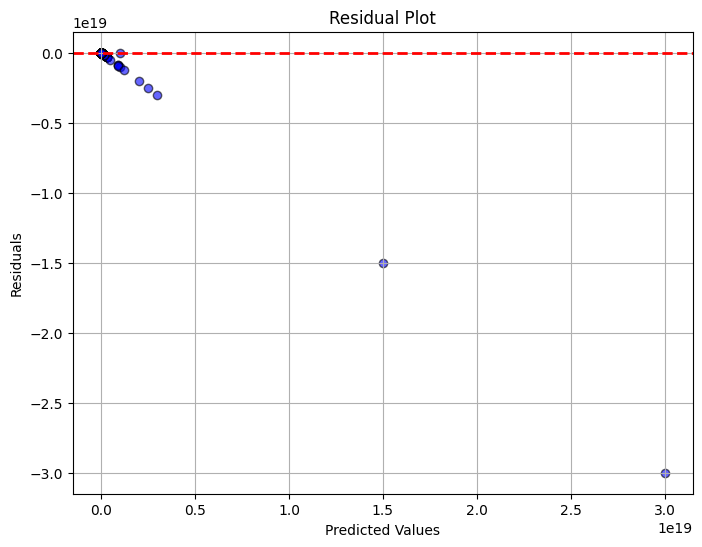


TAG Evaluation Metrics:
F1 Score (macro): 0.6179
Precision (macro): 0.6518
Recall (macro): 0.6046
Accuracy: 0.7219
Weighted F1 Score: 0.7166
Weighted Recall: 0.7219
Weighted Precision: 0.7182

Confusion Matrix:
[[304683  13598   1449 ...     10      9      3]
 [ 17256  94617    514 ...      9      2      0]
 [  1015    217  18196 ...      0      0      0]
 ...
 [     9      8      0 ...    145      0      0]
 [    19     31      5 ...      0     47      0]
 [     8      2      0 ...      0      0    131]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.82      0.80    373011
           1       0.74      0.69      0.71    136540
           2       0.63      0.73      0.68     24794
           3       0.80      0.89      0.85     19778
           4       0.60      0.57      0.58     19210
           5       0.77      0.81      0.79     18900
           6       0.86      0.92      0.89     15366
           7       0.85      0.

In [36]:
time_metrics = evaluate_classification(test_ground_truths['time'], test_predictions['time'], 'time')
scale_metrics = evaluate_classification(test_ground_truths['scale'], test_predictions['scale'], 'scale')
negative_metrics = evaluate_classification(test_ground_truths['negative'], test_predictions['negative'], 'negative')
fact_metrics = evaluate_regression(test_ground_truths['fact'], test_predictions['fact'], 'fact')
tag_metrics = evaluate_classification(test_ground_truths['tag'], test_predictions['tag'], 'tag')


#### scale & fact evaluation

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

def evaluate_scale(scale_true, scale_preds):
    scale_acc = accuracy_score(scale_true, scale_preds)
    scale_f1 = f1_score(scale_true, scale_preds, average='macro')
    
    print(f"Scale Accuracy: {scale_acc:.4f}")
    print(f"Scale F1-score: {scale_f1:.4f}")
    
    return scale_acc, scale_f1


In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_fact(fact_true, fact_preds, scale_true, scale_preds):
    # 轉換為 NumPy 陣列
    fact_true = np.asarray(fact_true)
    fact_preds = np.asarray(fact_preds)
    scale_true = np.asarray(scale_true)
    scale_preds = np.asarray(scale_preds)

    # 確保 fact 和 scale 的長度一致
    valid_mask = (scale_true != -100)  # 過濾無效 scale

    fact_true = fact_true[valid_mask]
    fact_preds = fact_preds[valid_mask]
    scale_true = scale_true[valid_mask]
    scale_preds = scale_preds[valid_mask]

    # 確保篩選後的長度相同
    if len(fact_true) != len(scale_true):
        print(f"Error: Mismatch in lengths after filtering! fact_true={len(fact_true)}, scale_true={len(scale_true)}")
        return None

    # 計算 scale 預測是否正確
    correct_scale_mask = (scale_preds == scale_true)  # Scale 預測正確的 mask
    incorrect_scale_mask = ~correct_scale_mask  # Scale 預測錯誤的 mask

    # 計算 RMSE、MAE、R²
    rmse = mean_squared_error(fact_true, fact_preds, squared=False)  # Root MSE
    mae = mean_absolute_error(fact_true, fact_preds)
    r2 = r2_score(fact_true, fact_preds)

    # 當 scale 預測正確時
    if correct_scale_mask.sum() > 0:
        rmse_correct = mean_squared_error(fact_true[correct_scale_mask], fact_preds[correct_scale_mask], squared=False)
        print(f"Fact RMSE (scale correct)  : {rmse_correct:.4f}")
    else:
        rmse_correct = None

    # 當 scale 預測錯誤時
    if incorrect_scale_mask.sum() > 0:
        rmse_incorrect = mean_squared_error(fact_true[incorrect_scale_mask], fact_preds[incorrect_scale_mask], squared=False)
        print(f"Fact RMSE (scale incorrect): {rmse_incorrect:.4f}")
    else:
        rmse_incorrect = None

    print(f"Fact RMSE: {rmse:.4f}")
    print(f"Fact MAE: {mae:.4f}")
    print(f"Fact R²: {r2:.4f}")

    return rmse, mae, r2, rmse_correct, rmse_incorrect


In [ ]:
# 先評估 scale 預測
scale_acc, scale_f1 = evaluate_scale(test_ground_truths['scale'], test_predictions['scale'])

# 再評估 fact 預測
evaluate_fact(test_ground_truths['fact'], test_predictions['fact'], test_ground_truths['scale'], test_predictions['scale'])